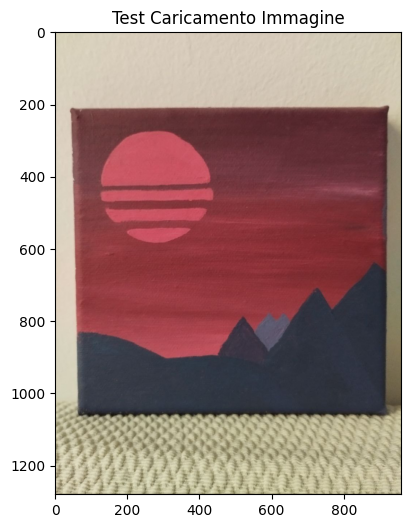

In [3]:
import cv2
import matplotlib.pyplot as plt
import os

# 1. Specifica il percorso di un'immagine che hai sul PC
# Se l'immagine è nella stessa cartella del notebook, scrivi solo il nome
img_path = 'C:\\tmp\\tramonto.jpg' 

if os.path.exists(img_path):
    # 2. Carica l'immagine con OpenCV
    image = cv2.imread(img_path)
    
    # 3. OpenCV carica in BGR, dobbiamo convertirla in RGB per Matplotlib
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    
    # 4. Visualizzala nel Notebook
    plt.figure(figsize=(10, 6))
    plt.imshow(image_rgb)
    plt.title("Test Caricamento Immagine")
    plt.axis('on') # Nasconde gli assi (pixel)
    plt.show()
else:
    print(f"Errore: Il file {img_path} non esiste!")

Immagine caricata: 960x1280 pixel


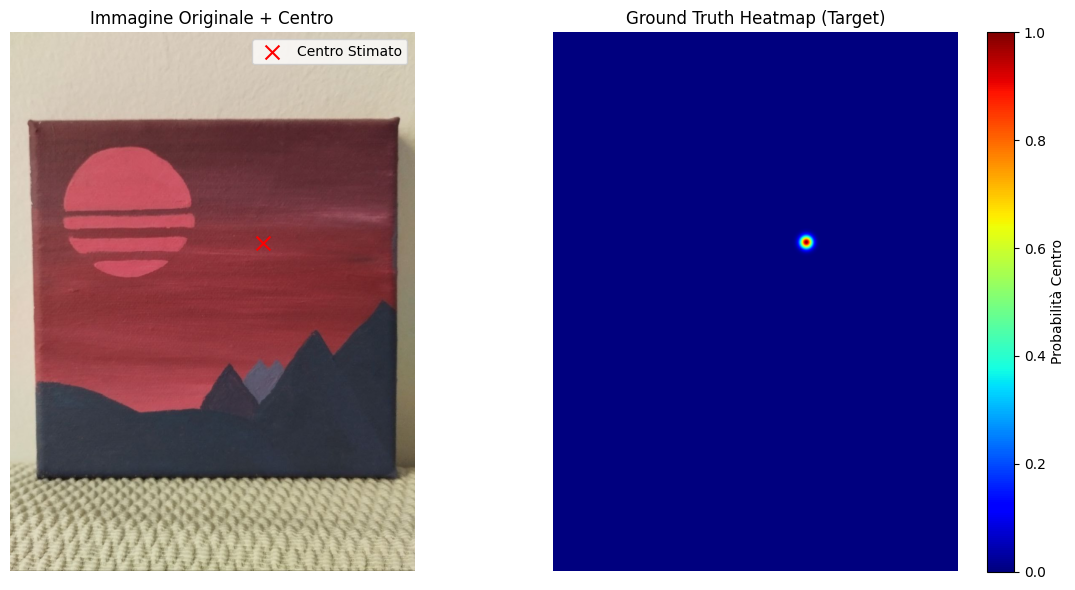

Passo 1 completato: Ground Truth generata con successo!


In [ ]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
import os

# --- CONFIGURAZIONE INIZIALE ---
# 1. Modifica con il nome del tuo file immagine di test
img_filename = 'C:\\tmp\\tramonto.jpg' 

# 2. Modifica con le coordinate (x, y) del centro dell'oggetto nell'immagine
# (Puoi stimarle guardando l'immagine, es. x=200, y=150)
center_x, center_y = 600,500

# 3. Parametro 'sigma' (deviazione standard) della Gaussiana.
# Controlla quanto è "larga" la macchia di calore.
sigma = 10 


# --- FUNZIONE PER GENERARE LA GAUSSIANA 2D ---
# Questa funzione crea la "macchia" di calore
def draw_gaussian(heatmap, center, sigma):
    tmp_heatmap = np.zeros_like(heatmap)
    height, width = heatmap.shape
    x, y = center
    
    # Crea una griglia di coordinate
    X, Y = np.meshgrid(np.arange(width), np.arange(height))
    
    # Calcola la formula della Gaussiana 2D centrata su (x, y)
    # H = exp( -((X-x)^2 + (Y-y)^2) / (2 * sigma^2) )
    dist_sq = (X - x)**2 + (Y - y)**2
    gaussian = np.exp(-dist_sq / (2 * sigma**2))
    
    # Assicuriamoci che il picco sia esattamente 1
    gaussian = gaussian / gaussian.max()
    
    # Uniamo la nuova gaussiana alla heatmap esistente (usando il max)
    # Nota: np.maximum è importante se avessimo più oggetti
    return np.maximum(heatmap, gaussian)


# --- ESECUZIONE DEL PASSO 1 ---
if not os.path.exists(img_filename):
    print(f"Errore: Il file {img_filename} non è stato trovato!")
else:
    # 1. Carica l'immagine originale (per vedere le dimensioni)
    img_bgr = cv2.imread(img_filename)
    height, width, _ = img_bgr.shape
    print(f"Immagine caricata: {width}x{height} pixel")

    # 2. Inizializza la Heatmap Ground Truth come una matrice di zeri
    # Deve avere le stesse dimensioni spaziali (H, W) ma 1 solo canale
    gt_heatmap = np.zeros((height, width), dtype=np.float32)

    # 3. Genera la Gaussiana sulla heatmap
    gt_heatmap = draw_gaussian(gt_heatmap, (center_x, center_y), sigma)
    
    # --- VISUALIZZAZIONE DEI RISULTATI ---
    plt.figure(figsize=(12, 6))

    # Sottoplot 1: Immagine Originale con il punto centrale
    plt.subplot(1, 2, 1)
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    plt.imshow(img_rgb)
    plt.scatter(center_x, center_y, color='red', marker='x', s=100, label='Centro Stimato')
    plt.title("Immagine Originale + Centro")
    plt.axis('off')
    plt.legend()

    # Sottoplot 2: La Ground Truth Heatmap risultante
    plt.subplot(1, 2, 2)
    # Usiamo cmap='hot' o 'jet' per visualizzare il calore
    plt.imshow(gt_heatmap, cmap='jet') 
    plt.title("Ground Truth Heatmap (Target)")
    plt.colorbar(label='Probabilità Centro') # Aggiunge la legenda dei colori
    plt.axis('off')

    plt.tight_layout()
    plt.show()

    print("Passo 1 completato: Ground Truth generata con successo!")


    